<a href="https://colab.research.google.com/github/hadasecohen/streaming-vae-anomaly-detection/blob/main/notebooks/cases/case02_cyclic_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case 2

# Do cyclic time features help an MLP-VAE detect contextual anomalies?

## Purpose of this notebook

This notebook demonstrates one of the central findings of the thesis:

> A simple feed-forward VAE can become much more effective at detecting time-dependent anomalies when calendar information is explicitly supplied **and reconstructed by the model**.

The thesis studies anomaly detection in streaming ERA5 weather data. It compares the impact of different configurations (VAE architecture, streaming and feature manipulation methods) on VAEs with different deep learning models as encoder/decoder.

This testcase focuses on **contextual anomalies**. These are observations whose values may look plausible in isolation, but the weather patterns are abnormal for the season.

---

For the complete experiment definitions, consult the thesis section associated with Table 4.23 (4.5.3 Effect of Cyclic Time Features).

## What is being compared?

The notebook runs three MLP-VAE variants:

| Variant | Cyclic time features provided as input? | Cyclic features reconstructed? | Meaning |
|---|---:|---:|---|
| **Plain MLP-VAE** | No | No | The model sees only weather variables. |
| **MLP-VAE Input-only cyclic** | Yes | No | Hour-of-day and day-of-year are supplied, but the decoder is not required to reproduce them. |
| **MLP-VAE-Cyclic** | Yes | Yes | The cyclic features are included in both the input and reconstruction target. |

The cyclic features are sine/cosine encodings of **hour of day** and **day of year**. This preserves their circular structure: for example, 23:00 is close to 00:00, and December is close to January.

## Findings being illustrated

The thesis found that merely appending cyclic features to the input produced little improvement. The large improvement occurred when those features were also part of the reconstruction objective.

The proposed interpretation is that reconstruction pressure encourages the latent representation to retain calendar phase. This gives the MLP access to temporal context without requiring an LSTM or Transformer.

This reduced notebook uses a shorter ERA5 period than the full thesis experiments. Therefore, the exact metric values are not expected to match the thesis. The important result is the **relative pattern across the three variants**.

---

## What this notebook will do

1. Check whether a GPU is available.
2. Clone and install the thesis repository.
3. Run the three experiment variants using the same reduced ERA5 slice.
4. Collect F1, AUC, precision, recall, and confusion-matrix counts.
5. Display plots that compare anomaly-score separation and F1.

### Expected runtime

Window-based runs use the GPU when available. Additionally, MLP based models are lighter than LSTM and Transformer.
All tests are expected to execute relatively fast

# Run Case

### Check GPU availability

In [1]:
import torch

print("Environment check")
print("-----------------")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Selected device:", torch.cuda.get_device_name(0))
else:
    print(
        "No GPU was detected. The notebook can still run, but "
        "window-based training may be slower."
    )


Environment check
-----------------
PyTorch version: 2.11.0+cu128
CUDA available: True
Selected device: Tesla T4


### Import and/or load Repo

In [2]:
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/hadasecohen/streaming-vae-anomaly-detection.git"
REPO_DIR = Path("/content/repo") if "COLAB_RELEASE_TAG" in os.environ else Path("repo")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not REPO_DIR.exists():
        subprocess.run(
            ["git", "clone", REPO_URL, str(REPO_DIR)],
            check=True,
        )

    os.chdir(REPO_DIR)
else:
    # When launched from notebooks/cases inside a local checkout,
    # move to the repository root.
    if not Path("scripts/run_all_trials.py").exists():
        os.chdir("../..")

print("Working directory:", os.getcwd())
print("Installing the project dependencies...")
subprocess.run(
    ["python", "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    check=True,
)
%env MPLBACKEND=Agg
print("Setup complete.")


Working directory: /content/repo
Installing the project dependencies...
env: MPLBACKEND=Agg
Setup complete.


### Step 1 — Configure the run

In [3]:
import os
import yaml

CASE_ID = "case02_cyclic_features"
SESSION_DIR = "runs/trials_suite"
OUTPUT_DIR = f"{SESSION_DIR}/{CASE_ID}"

# Edit this directly — works the same locally and on Colab:
#   "full_split_files" (default) -> anom_types/contextual.yaml's own default —
#                      full-scale contextual data, pre-split into a
#                      warmup-only file (shared with case01 — the warmup
#                      portion is anomaly-free and identical regardless of
#                      anomaly type) and a test-only file with the
#                      contextual anomalies injected. Committed to the repo.
#   "mini_50pct"    -> the in-repo 377,784-row ERA5 slice (~50% of full-scale).
#                      Committed to the repo.
#   "mini_28pct"    -> the in-repo 210,384-row ERA5 slice (~28% of full-scale).
#                      Local-only, not shipped — see DATA_LICENSE.md.
DATA_SOURCE = "full_split_files"

_DATA_SOURCE_LAYERS = {
    "full_split_files": None,   # anom_types/contextual.yaml's own default — no extra layer needed
    "mini_50pct": "../../modules/data_source/mini_50pct_contextual.yaml",
    "mini_28pct": "../../modules/data_source/mini_28pct_contextual.yaml",
}

_suite_source_path = f"notebooks/cases/{CASE_ID}_suite.yaml"
_suite_dir = os.path.dirname(os.path.abspath(_suite_source_path))

def _resolve(path):
    # base_config / config_layers entries are relative paths meant to be
    # read relative to the suite file's own directory (notebooks/cases/).
    # Resolving them to absolute paths here — rather than leaving them
    # relative — means the resolved copy stays correct no matter how deep
    # under OUTPUT_DIR it ends up being written.
    return path if os.path.isabs(path) else os.path.normpath(os.path.join(_suite_dir, path))

_data_source_layer = _DATA_SOURCE_LAYERS[DATA_SOURCE]

with open(_suite_source_path) as f:
    _suite = yaml.safe_load(f)

_suite["base_config"] = _resolve(_suite["base_config"])
for _run in _suite["runs"]:
    _layers = [_resolve(p) for p in _run["config_layers"]]
    if _data_source_layer:
        _layers.append(_resolve(_data_source_layer))
    _run["config_layers"] = _layers

# Written under OUTPUT_DIR (runs/, already gitignored and read-write) rather
# than notebooks/ (source-controlled, meant to stay read-only) — os.makedirs
# because OUTPUT_DIR won't exist yet on a fresh run.
os.makedirs(OUTPUT_DIR, exist_ok=True)
SUITE_PATH = f"{OUTPUT_DIR}/{CASE_ID}_suite_resolved.yaml"
with open(SUITE_PATH, "w") as f:
    yaml.safe_dump(_suite, f, sort_keys=False)

print(f"DATA_SOURCE = {DATA_SOURCE!r} -> {_data_source_layer}")

DATA_SOURCE = 'full_split_files' -> None


#### Configuration file

The notebooks test suites combines a shared ERA5 configuration (`modules/era5_common.yaml`) with the architecture, anomaly type, stream mode, and cyclic-feature settings for each run.

`DATA_SOURCE` may be configured to choose other datasets from the era5 data directory.

- `"full_split_files"` — full-scale contextual data. This is `modules/anom_types/contextual.yaml`'s own default. Where warmup and test files are split. The warmup portion in file `data/era5/full_scale/split/era5_clean_warmup.csv` is anomaly-free and identical regardless of anomaly type. The test-only file differs per anomaly type injected. In this case, as contextual anomalies are injected, the test file used is `data/era5/full_scale/split/era5_contextual_test.csv`.

- `"mini_50pct"` — the in-repo 377,784-row ERA5 slice (`data/era5/mini_50pct/era5_contextual_anomalies.csv`, ~50% of full-scale. See `case01_clean_baseline.ipynb`).

- `"mini_28pct"` — an even smaller in-repo 210,384-row slice (`data/era5/mini_28pct/`, ~28% of full-scale).  See `case01_clean_baseline.ipynb`.

All variants use the same base configuration and evaluation procedure. The intended comparison is therefore the effect of **how cyclic information is supplied to the MLP-VAE**.

#### Output Directory

During execution, the script creates a separate run directory in the repo for each variant under `OUTPUT_DIR` (`runs/trials_suite/case02_cyclic_features` by default).

`notebooks/cases/case02_cyclic_features_suite.yaml` layers `modules/era5_common.yaml` with the architecture / anomaly-type / stream-mode / feature-engineering fragments for each of the runs below (see the suite file for the exact overrides).

### Step 2 Run the testsuite

### Command:

**If this fails with `ModuleNotFoundError: No module named 'src.utils'`**, please [open a GitHub issue](https://github.com/hadasecohen/streaming-vae-anomaly-detection/issues/new) with the full traceback rather than trying to fix it locally — it means the compiled `src/` no longer matches Colab's Python version and needs to be recompiled and re-released.

In [4]:
!python scripts/run_all_trials.py {SUITE_PATH} \
    --session {SESSION_DIR} --skip-existing

[suite] log     : /content/repo/runs/trials_suite/suite.log
[suite] suite   : /content/repo/runs/trials_suite/case02_cyclic_features/case02_cyclic_features_suite_resolved.yaml
[suite] session : /content/repo/runs/trials_suite
[suite] base cfg: /content/repo/modules/era5_common.yaml
[suite] module  : scripts.trial.run_trial
[suite] GPUs    : [0]  (1 slot(s))
[suite] 3 run(s) planned:
  [  1] MLP_plain  [case02_cyclic_features/case02_cyclic_features_suite_resolved]  (module: scripts.trial.run_trial)
  [  2] MLP_cyclic_input_only  [case02_cyclic_features/case02_cyclic_features_suite_resolved]  (module: scripts.trial.run_trial)
  [  3] MLP_cyclic_recon  [case02_cyclic_features/case02_cyclic_features_suite_resolved]  (module: scripts.trial.run_trial)
[suite] --skip-existing: completed runs will be skipped
[suite] START  'MLP_cyclic_input_only'  (GPU=0)
GLOBAL SEED = 49
Logger: Verbosity=3, logging into: '/content/repo/runs/trials_suite/case02_cyclic_features/case02_cyclic_features_suite_res

### Step 3 — Build a common comparison

#### The next command reads the predictions from every run and produces:

- a common performance table
- anomaly-score histograms
- an F1 comparison across variants
- confusion-matrix summaries
- seed-stability diagnostics, where applicable.

These outputs are saved under `OUTPUT_DIR/cross_compare/`.

### Command:

In [5]:
!python scripts/cross_compare.py {OUTPUT_DIR}

[cross] session : runs/trials_suite/case02_cyclic_features
[cross] output  : runs/trials_suite/case02_cyclic_features/cross_compare
[cross] 3 run(s) found:
  MLP_Contextual_input_only                           arch=MLP  anomaly=Contextual  cyclic=False  mode=window
  MLP_Contextual_off                                  arch=MLP  anomaly=Contextual  cyclic=False  mode=window
  MLP_Contextual_recon                                arch=MLP  anomaly=Contextual  cyclic=False  mode=window

[cross] Loading run data ...
  MLP_Contextual_input_only ... ok
  MLP_Contextual_off ... ok
  MLP_Contextual_recon ... ok

[cross] Writing outputs ...
  saved performance_table.csv
  saved performance_summary.txt

  ══ Contextual anomalies ══════════════════════════════════════════════════════════════════════════════════════════
  run_name                                     arch       variant              F1    AUC   Prec    Rec    Acc       TP      FP       TN     FN    #params
  ──────────────────────────

### Step 4 — Quantitative Results

### Command:

In [6]:
import pandas as pd
from IPython.display import display

performance_path = f"{OUTPUT_DIR}/cross_compare/performance_table.csv"
perf = pd.read_csv(performance_path)

columns = [
    "run_name", "arch", "anomaly", "variant",
    "f1", "auc", "precision", "recall",
    "tp", "fp", "fn",
]

print("Comparison of cyclic-feature variants")
display(
    perf[columns]
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
    .style.format({
        "f1": "{:.3f}",
        "auc": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
    })
)

Comparison of cyclic-feature variants


,run_name,arch,anomaly,variant,f1,auc,precision,recall,tp,fp,fn
0,MLP_Contextual_recon,MLP,Contextual,recon,0.718,0.953,0.772,0.672,589,174,288
1,MLP_Contextual_off,MLP,Contextual,off,0.500,0.905,0.638,0.410,360,204,517
2,MLP_Contextual_input_only,MLP,Contextual,input_only,0.396,0.892,0.417,0.377,331,462,546


#### Focus first on the `f1` column because F1 is the main thesis metric. Precision and recall help explain *why* F1 changes:

- higher **precision** means fewer normal observations were falsely flagged;
- higher **recall** means more contextual anomalies were detected;
- `tp`, `fp`, and `fn` show the corresponding counts.

#### The full thesis result was:

```text
Plain MLP-VAE  ~=  MLP-VAE Input-only cyclic  <  MLP-VAE-Cyclic
```

The testcase is successful when the reconstructed-cyclic variant shows a clear advantage, even if the exact values differ from the thesis.

### Step 5 — Qualitative support (Plots)

#### Score histograms

##### Command:

Score histograms (normal vs anomaly), one file per architecture:


MLP

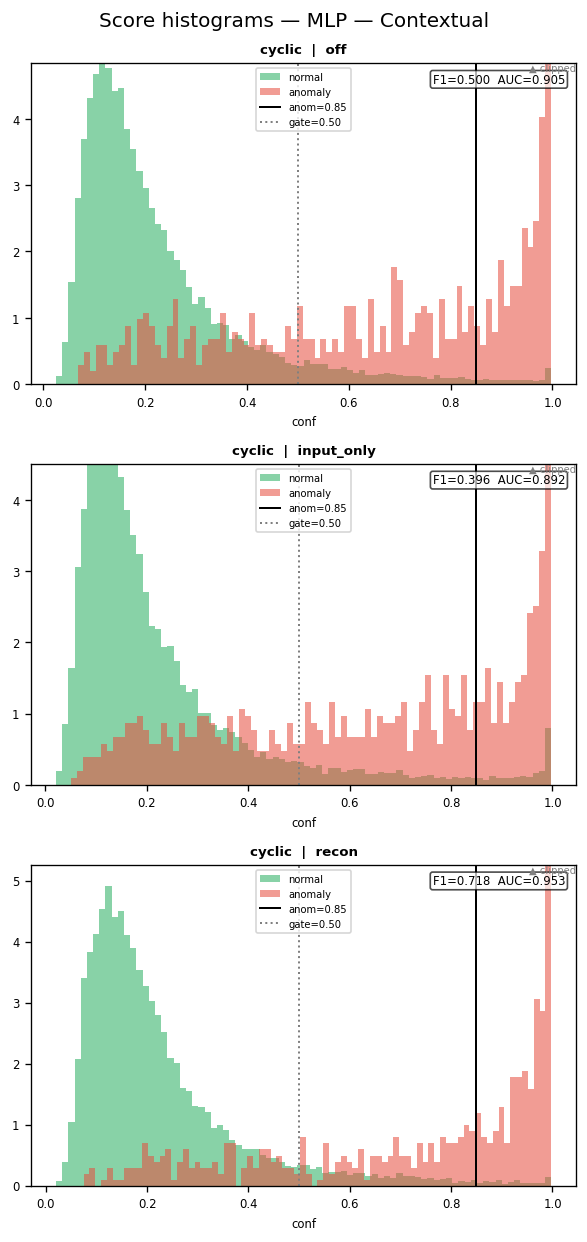

In [7]:
# Display the key comparison plot(s) inline, 2 per row, captioned by filename
import base64
import glob
from IPython.display import HTML, display

paths = sorted(glob.glob(f"{OUTPUT_DIR}/cross_compare/contextual/score_hist_*.png"))
print("Score histograms (normal vs anomaly), one file per architecture:")

n_cols = 2
rows_html = []
for i in range(0, len(paths), n_cols):
    row_paths = paths[i:i + n_cols]
    cells = []
    for path in row_paths:
        # caption from the filename (score_hist_{arch}.png), not the image
        # pixels — reliable because cross_compare.py names the file after
        # the architecture it plots.
        label = path.split("/")[-1].removeprefix("score_hist_").removesuffix(".png")
        with open(path, "rb") as f:
            b64 = base64.b64encode(f.read()).decode("ascii")
        cells.append(
            f'<td style="width:{100 // n_cols}%; padding:4px; text-align:center; vertical-align:top;">'
            f'<div style="font-weight:600; margin-bottom:4px;">{label}</div>'
            f'<img src="data:image/png;base64,{b64}" style="max-width:100%;"></td>'
        )
    rows_html.append("<tr>" + "".join(cells) + "</tr>")

display(HTML(f'<table style="width:100%; border-collapse:collapse;">{"".join(rows_html)}</table>'))

Better separation means the model assigns more distinct scores to contextual anomalies.

#### F1 plot

Gives the direct comparison across variants.

##### Command

F1-vs-variant line plot:


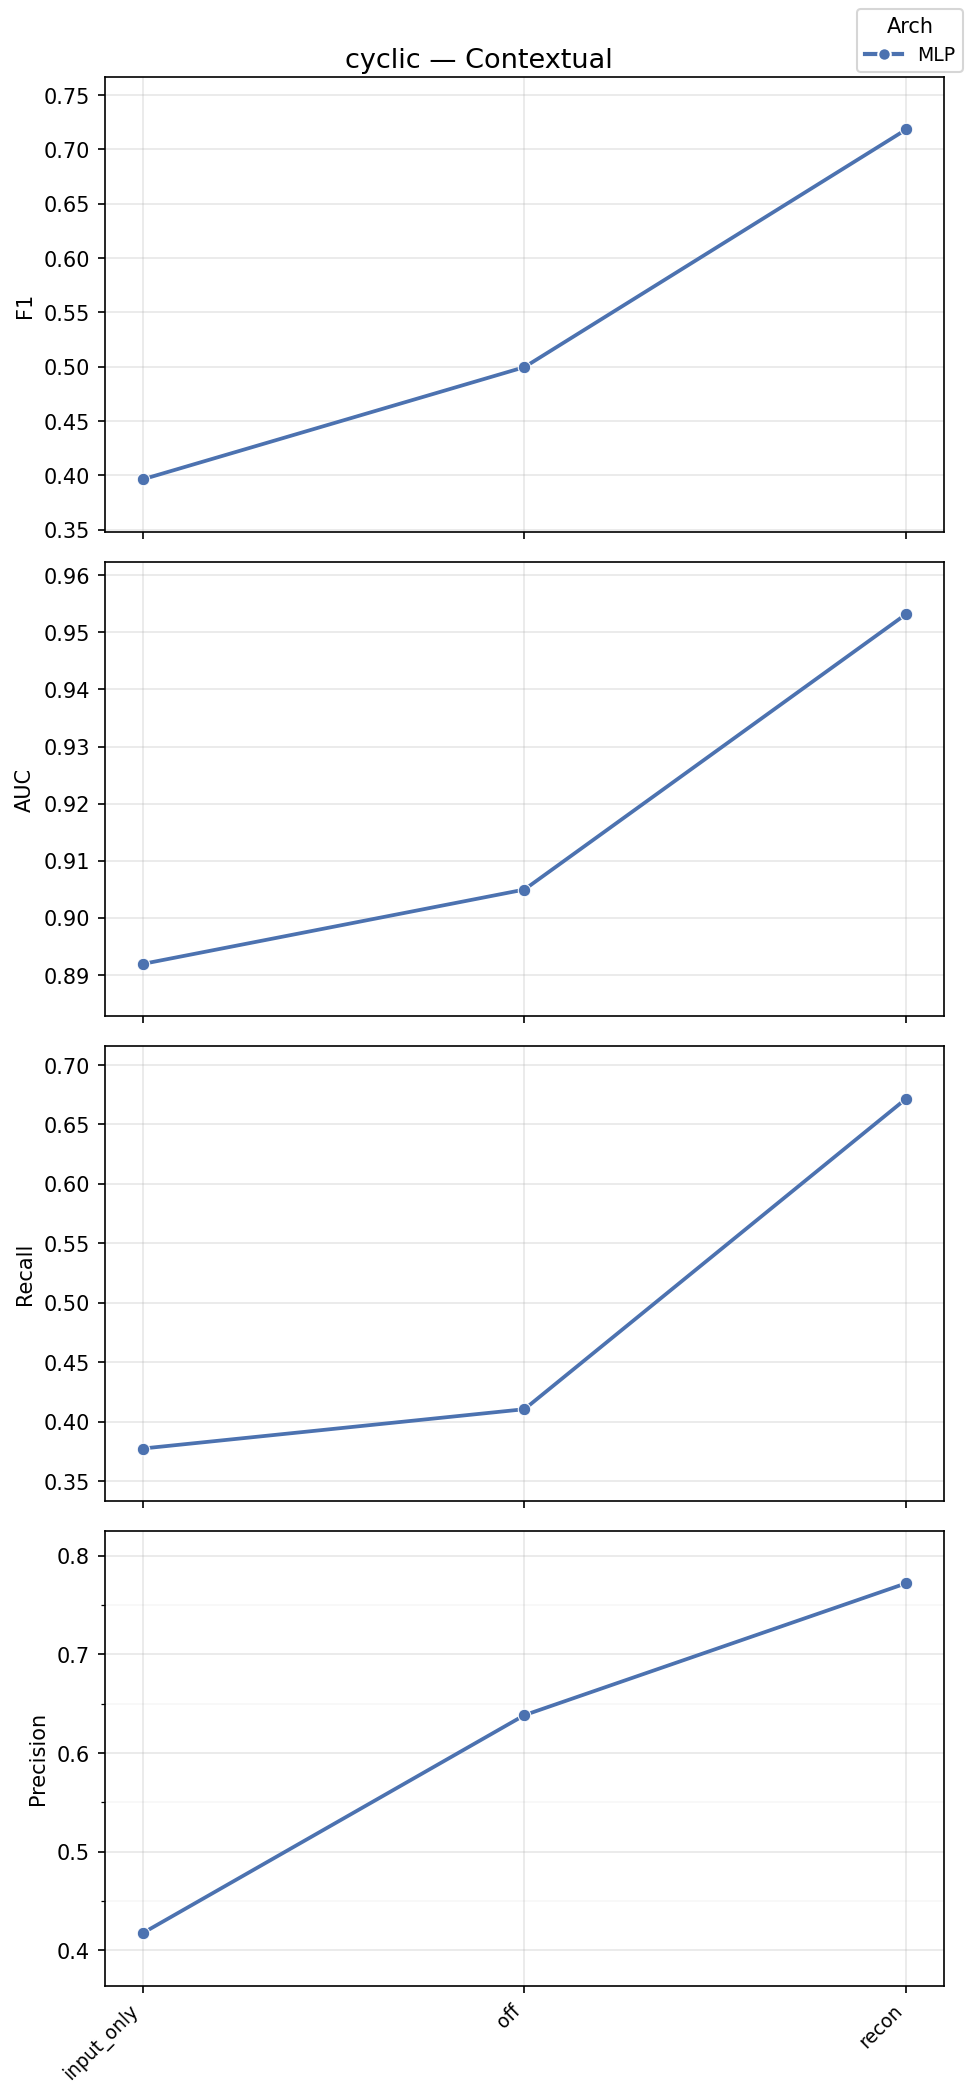

In [8]:
# Display the key comparison plot(s) inline
import glob
from IPython.display import Image, display
print("F1-vs-variant line plot:")
for p in sorted(glob.glob(f"{OUTPUT_DIR}/cross_compare/contextual/section_lines_cyclic.png")):
    display(Image(filename=p))

#### The plots can indicate, among other things:

1. Whether the input-only cyclic MLP-VAE variant differs meaningfully from the plain MLP-VAE
2. Whether reconstructing the cyclic features increases separation between normal and anomalous scores
3. Whether the resulting F1 improvement is caused mainly by better recall, better precision, or both.

### Main takeaway

A time feature is not necessarily useful simply because it is present in the input. In this experiment, its effect depends on the learning objective. Requiring the model to reconstruct the cyclic variables encourages the latent code to preserve temporal phase, allowing a simple MLP-VAE to recognise anomalies whose abnormality depends on calendar context.

## Scope of this testcase

This notebook is a compact demonstration, not a full reproduction of every result reported in the thesis. With `DATA_SOURCE = "full_split_files"` (the default) it runs on the full-scale contextual data. With `DATA_SOURCE = "mini_50pct"` / `"mini_28pct"` a shorter ERA5 interval is used instead — useful for a quick check, but see `case01_clean_baseline.ipynb` for why it can give a different architecture ranking than the full-scale data.

Differences from the full thesis metrics are still possible even with `"full_split_files"` (single seed, this repo's own port of the training code). Conclusions should be based on the direction and consistency of the comparison rather than exact numerical agreement.

### Download all runs in this notebook

Off by default — see the cell below to enable it.

In [ ]:
# Set to True and re-run this cell to download a zip of the run directory
# (OUTPUT_DIR), covering all runs in this notebook.
DOWNLOAD_RUN_DIR = False

import shutil

if not DOWNLOAD_RUN_DIR:
    print(
        "Run directory not downloaded (DOWNLOAD_RUN_DIR=False). "
        "To download it, set DOWNLOAD_RUN_DIR = True above and re-run this cell."
    )
else:
    from google.colab import files

    archive_path = shutil.make_archive(OUTPUT_DIR.rstrip("/").replace("/", "_"), "zip", OUTPUT_DIR)
    print(f"Zipped {OUTPUT_DIR} -> {archive_path}")
    files.download(archive_path)